In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import os
import sys
import django
import torch

# Setup Django environment
# Adjust the path to point to the directory containing manage.py
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../hiccup_ide")))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "hiccup_ide.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
django.setup()

In [4]:
from neural_data.models import Model, Input
import torch
from pt_to_api.mnist import SimpleMNIST
from pt_to_api.utils import show_single_channel_red_green_black as S, to_show_list as tsl

model = SimpleMNIST()
model.load_state_dict(torch.load(Model.objects.first().pt_file.path, "cpu"))
inp = torch.load(Input.objects.get(alias="4-Sl1").pt_file.path, "cpu", weights_only=False)

Coordinate to build the map of
```python
coord = Conv2dOutputCoordinate(
    type="Conv2dOutputCoordinate",
    layer_type="conv2d",
    coordinate_type="output",
    layer_name="layers.2",
    channel=12,
    y=2,
    x=3,
)
```

In [16]:
inp.shape

torch.Size([1, 1, 28, 28])

In [5]:
from pt_to_api.utils import zeros_with_1_at
from pt_to_api.mnist import get_contribs_for_inp_vectorized
contribs, _, _ = get_contribs_for_inp_vectorized(inp, model, zeros_with_1_at(10, 4), "layers.5", "cpu")

array([<Axes: >, <Axes: >], dtype=object)

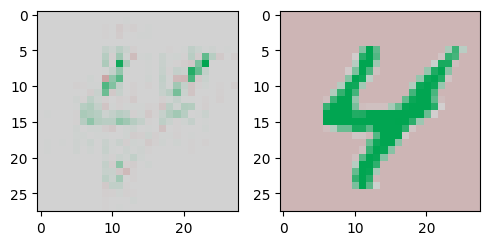

In [6]:
S([contribs["x"][0][0], inp[0][0]], viztype="local", mode="light")

In [24]:
contribs["layers.2"].shape

torch.Size([1, 16, 7, 7])

In [7]:
interm = torch.zeros(contribs["layers.2"].shape).float()
interm[0, 12, 6, 3] = 1.0
ic_12_6_3, _, _ = get_contribs_for_inp_vectorized(inp, model, interm, "layers.2", "cpu")

In [9]:
interm = torch.zeros(contribs["layers.2"].shape).float()
interm[0, 12, 2, 6] = 1.0
ic_12_2_6, _, _ = get_contribs_for_inp_vectorized(inp, model, interm, "layers.2", "cpu")

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

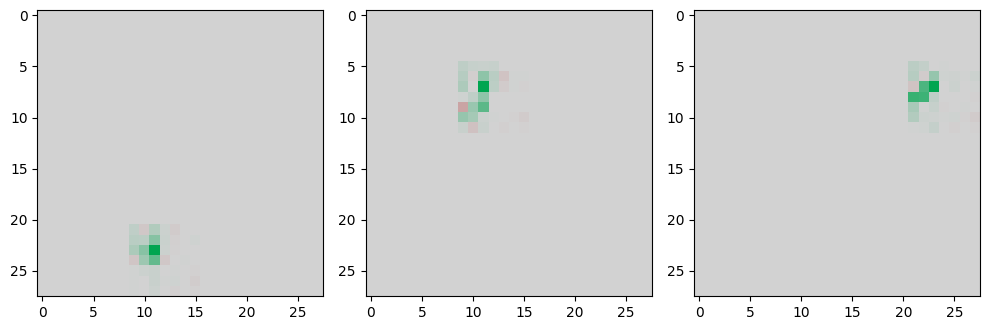

In [11]:
interm = torch.zeros(contribs["layers.2"].shape).float()
interm[0, 12, 2, 3] = 1.0
ic_12_2_3, _, _ = get_contribs_for_inp_vectorized(inp, model, interm, "layers.2", "cpu")
S([ic_12_6_3["x"][0][0], ic_12_2_3["x"][0][0], ic_12_2_6["x"][0][0]], 10, 3, viztype="local", mode="light")

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

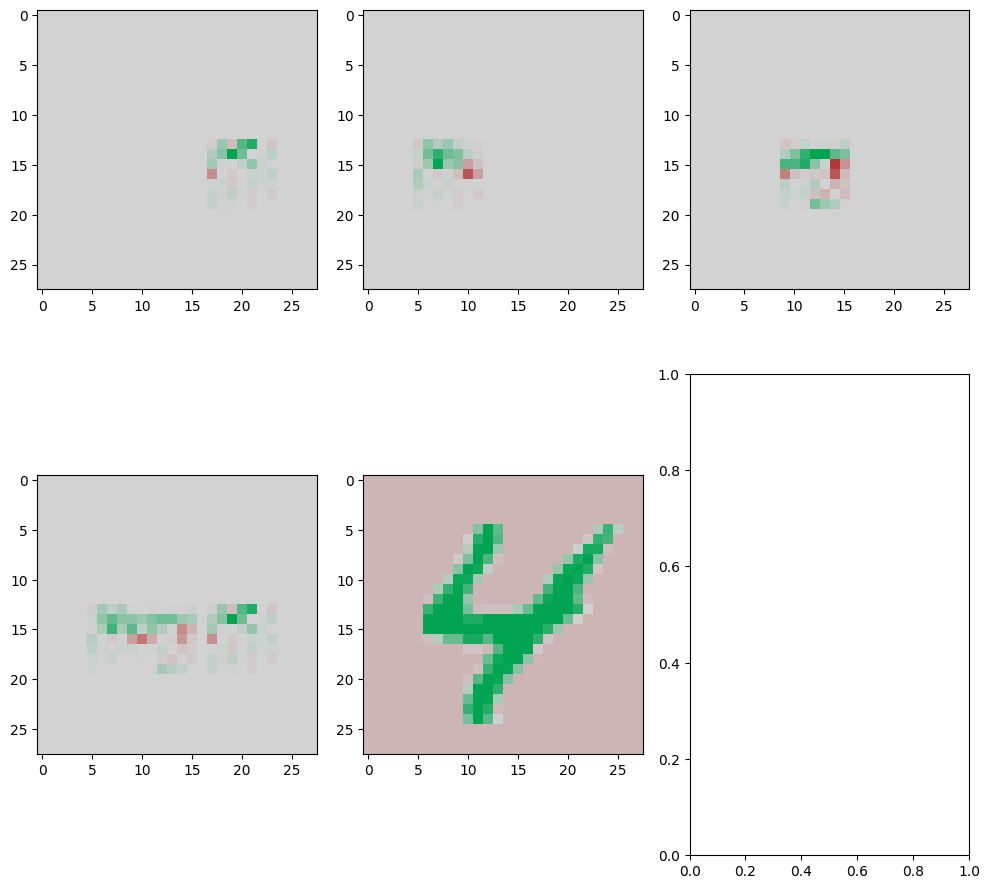

In [18]:
interm = torch.zeros(contribs["layers.2"].shape).float()
interm[0, 5, 4, 5] = 1.0
ic_5_4_5, _, _ = get_contribs_for_inp_vectorized(inp, model, interm, "layers.2", "cpu")

interm = torch.zeros(contribs["layers.2"].shape).float()
interm[0, 5, 4, 2] = 1.0
ic_5_4_2, _, _ = get_contribs_for_inp_vectorized(inp, model, interm, "layers.2", "cpu")

interm = torch.zeros(contribs["layers.2"].shape).float()
interm[0, 5, 4, 3] = 1.0
ic_5_4_3, _, _ = get_contribs_for_inp_vectorized(inp, model, interm, "layers.2", "cpu")


ic_5_all = ic_5_4_5["x"][0][0] + ic_5_4_2["x"][0][0] + ic_5_4_3["x"][0][0]

S([ic_5_4_5["x"][0][0], ic_5_4_2["x"][0][0], ic_5_4_3["x"][0][0], ic_5_all, inp[0][0]], 10, 3, viztype="local", mode="light")